In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Positional Encoding

In [2]:
def positional_encoding(seq_len, embedding_size):
    positions = np.arange(seq_len)[:, np.newaxis]  # shape (seq_len, 1)
    dims = np.arange(embedding_size)[np.newaxis, :]  # shape (1, embedding_dim)     

    denominator = np.power(
        10000, 
        (2*(dims//2)) / np.float32(embedding_size)
    )

    pe = positions / denominator  # shape (seq_len, embedding_dim)

    pe[:, 0::2] = np.sin(pe[:, 0::2])  # start from 0, step 2 --> 0,2,4...
    pe[:, 1::2] = np.cos(pe[:, 1::2])  # start from 1, step 2 --> 1,3,5,...

    pe = pe[np.newaxis, ...]  # (1, seq_len, embedding_dim) --> 1 represents for batch_size
    # to make pe_layer (broadcasted) to plus with embedding_layer: (1, seq_len, embedding_dim) + (batch_size, seq_len, embedding_dim) 
    # any token with the same position in any sequence will have the same pe_vector

    return tf.cast(pe, dtype=tf.float32)  # convert to tensor

In [3]:
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

pe_matrix = positional_encoding(MAX_SEQUENCE_LENGTH, EMBEDDING_DIM)
pe_matrix

<tf.Tensor: shape=(1, 100, 100), dtype=float32, numpy=
array([[[ 0.0000000e+00,  1.0000000e+00,  0.0000000e+00, ...,
          1.0000000e+00,  0.0000000e+00,  1.0000000e+00],
        [ 8.4147096e-01,  5.4030228e-01,  7.3912054e-01, ...,
          1.0000000e+00,  1.2022645e-04,  1.0000000e+00],
        [ 9.0929741e-01, -4.1614684e-01,  9.9570352e-01, ...,
          9.9999994e-01,  2.4045288e-04,  1.0000000e+00],
        ...,
        [ 3.7960774e-01, -9.2514753e-01, -8.4164554e-01, ...,
          9.9990171e-01,  1.1661701e-02,  9.9993199e-01],
        [-5.7338190e-01, -8.1928825e-01, -1.6776237e-01, ...,
          9.9989969e-01,  1.1781919e-02,  9.9993062e-01],
        [-9.9920684e-01,  3.9820880e-02,  6.1564511e-01, ...,
          9.9989760e-01,  1.1902137e-02,  9.9992919e-01]]], dtype=float32)>

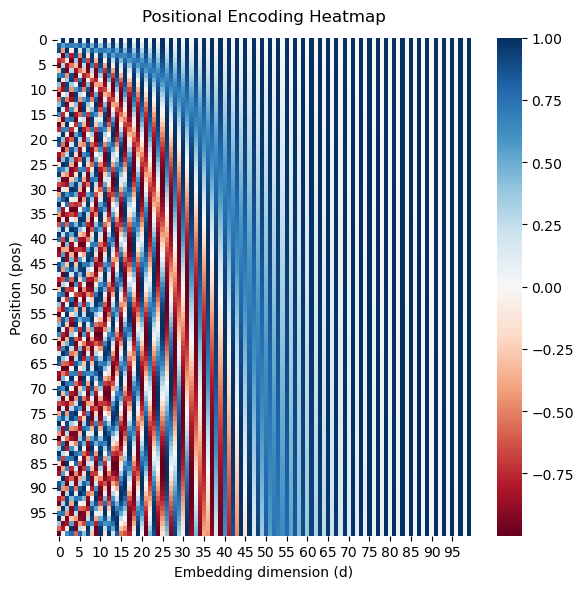

In [4]:
plt.figure(figsize=(6, 6))
sns.heatmap(pe_matrix[0], cmap="RdBu", cbar=True, xticklabels=5, yticklabels=5)

plt.xlabel("Embedding dimension (d)")
plt.ylabel("Position (pos)")
plt.title("Positional Encoding Heatmap", pad=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Property 1: Length of Position Vectors

In [5]:
# apply norm for the second axis (positions, dim) to compute magnitude of each pos_vector
pos_length = tf.linalg.norm(pe_matrix[0], axis=1)  
pos_length

<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 ,
       7.071068 , 7.071068 , 7.0710683, 7.071068 , 7.0710673, 7.071068 ,
       7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 ,
       7.0710683, 7.071068 , 7.071068 , 7.0710673, 7.071068 , 7.071068 ,
       7.071068 , 7.071068 , 7.071068 , 7.0710673, 7.071068 , 7.071068 ,
       7.0710673, 7.071068 , 7.071068 , 7.071068 , 7.0710673, 7.0710673,
       7.071068 , 7.071068 , 7.0710673, 7.0710673, 7.071068 , 7.071068 ,
       7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 ,
       7.071068 , 7.0710673, 7.071068 , 7.071068 , 7.071068 , 7.071068 ,
       7.071068 , 7.071068 , 7.071068 , 7.0710683, 7.071068 , 7.071068 ,
       7.071068 , 7.071068 , 7.071068 , 7.0710673, 7.071068 , 7.0710683,
       7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 ,
       7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 , 7.071068 ,
   

In [6]:
tf.sqrt(EMBEDDING_DIM / 2)

<tf.Tensor: shape=(), dtype=float32, numpy=7.071068>

### Property 2: Distance between Position Vectors

In [7]:
def compute_distance(pe_matrix, k):
    """
    Computes the L2 norm of the difference between positional encoding vectors
    separated by k positions.

    Args:
        pos_encoding (tf.Tensor): Positional encoding tensor of shape (1, seq_len, d_model).
        k (int): Distance between positions to compare.

    Returns:
        tf.Tensor: 1D tensor of shape (seq_len - k,) containing the L2 norm of
                   the difference between PE[pos] and PE[pos + k] for all valid positions.
    """
    
    seq_len = pe_matrix.shape[1]
    distances = []

    for pos in range(seq_len - k):
        distance = tf.linalg.norm(pe_matrix[0, pos, :] - pe_matrix[0, pos + k, :])
        distances.append(distance.numpy())

    return tf.stack(distances)

In [8]:
k = 5
distance_by_k = compute_distance(pe_matrix, k)
distance_by_k

<tf.Tensor: shape=(95,), dtype=float32, numpy=
array([5.1352954, 5.1352954, 5.1352954, 5.1352954, 5.135296 , 5.1352954,
       5.1352954, 5.135296 , 5.1352954, 5.1352954, 5.135296 , 5.135296 ,
       5.1352954, 5.1352954, 5.1352954, 5.135296 , 5.135296 , 5.1352954,
       5.135296 , 5.1352954, 5.1352954, 5.1352954, 5.135296 , 5.1352954,
       5.1352954, 5.1352954, 5.135296 , 5.135296 , 5.1352954, 5.135296 ,
       5.135296 , 5.1352954, 5.1352954, 5.135296 , 5.135296 , 5.135296 ,
       5.135296 , 5.135296 , 5.1352954, 5.1352954, 5.1352954, 5.1352954,
       5.1352954, 5.1352954, 5.1352954, 5.1352954, 5.1352954, 5.1352954,
       5.1352954, 5.1352954, 5.135296 , 5.135296 , 5.135296 , 5.1352954,
       5.1352954, 5.1352954, 5.135296 , 5.1352954, 5.1352954, 5.135296 ,
       5.1352954, 5.1352954, 5.1352954, 5.1352954, 5.1352954, 5.1352954,
       5.135296 , 5.1352954, 5.1352954, 5.1352954, 5.1352954, 5.1352954,
       5.1352954, 5.135296 , 5.135296 , 5.1352954, 5.1352954, 5.1352954,
    

In [9]:
def compute_distances_for_k_values(pe_matrix, k_values):
    results = {}
    for k in k_values:
        distance_tensor = compute_distance(pe_matrix, k)
        results[k] = distance_tensor.numpy()[0]
    return results

In [10]:
k_values = range(1, MAX_SEQUENCE_LENGTH, 1)
k_to_distance_dict = compute_distances_for_k_values(pe_matrix, k_values)

k_values, distances = zip(*k_to_distance_dict.items())

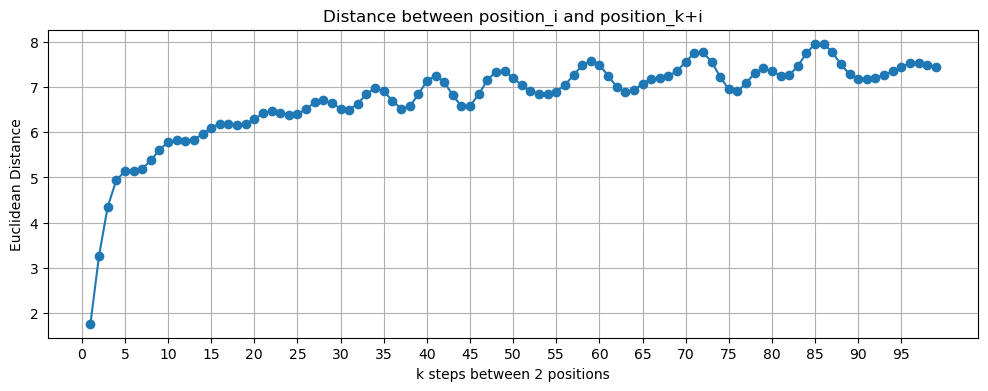

In [11]:
plt.figure(figsize=(12,4))
plt.plot(k_values, distances, marker='o')
plt.xticks(range(0, MAX_SEQUENCE_LENGTH, 5))

plt.title("Distance between position_i and position_k+i")
plt.xlabel("k steps between 2 positions")
plt.ylabel("Euclidean Distance")


plt.grid(True)
plt.show()

### Property 3: Dot Product between Position Vectors

In [12]:
def compute_dot_product(pe_matrix, k):
    """
    Computes the dot product between positional encoding vectors
    separated by k positions.

    Args:
        pe_matrix (tf.Tensor): Positional encoding tensor of shape (1, seq_len, d_model).
        k (int): Distance between positions to compare.

    Returns:
        tf.Tensor: 1D tensor of shape (seq_len - k,) containing the dot product
                   between PE[pos] and PE[pos + k] for all valid positions.
    """
    
    seq_len = pe_matrix.shape[1]
    dots = []

    for pos in range(seq_len - k):
        dot = tf.tensordot(pe_matrix[0, pos, :], pe_matrix[0, pos + k, :], axes=1)
        dots.append(dot.numpy())

    return tf.stack(dots)

In [13]:
k = 5
dot_by_k = compute_dot_product(pe_matrix, k)
dot_by_k

<tf.Tensor: shape=(95,), dtype=float32, numpy=
array([36.814373, 36.81437 , 36.81437 , 36.81437 , 36.81437 , 36.814373,
       36.814377, 36.81437 , 36.814373, 36.81436 , 36.814373, 36.81437 ,
       36.814377, 36.81437 , 36.81437 , 36.81437 , 36.814373, 36.814365,
       36.814373, 36.814373, 36.81437 , 36.81437 , 36.81437 , 36.814365,
       36.81437 , 36.814373, 36.814373, 36.814373, 36.81437 , 36.814373,
       36.81438 , 36.814365, 36.814365, 36.814373, 36.81437 , 36.81437 ,
       36.814373, 36.81437 , 36.81437 , 36.814373, 36.814373, 36.81437 ,
       36.814365, 36.814373, 36.81437 , 36.81437 , 36.81437 , 36.814373,
       36.814377, 36.814373, 36.81436 , 36.814373, 36.81437 , 36.814373,
       36.81436 , 36.814377, 36.814377, 36.814365, 36.81437 , 36.814373,
       36.81437 , 36.814373, 36.814377, 36.814373, 36.81437 , 36.814373,
       36.814373, 36.814373, 36.81437 , 36.814365, 36.81437 , 36.814373,
       36.814365, 36.81437 , 36.814365, 36.814373, 36.814365, 36.814373,
    

In [14]:
def compute_dots_for_k_values(pe_matrix, k_values):
    results = {}
    for k in k_values:
        dot_tensor = compute_dot_product(pe_matrix, k)
        results[k] = dot_tensor.numpy()[0]
    return results

In [15]:
k_values = range(1, MAX_SEQUENCE_LENGTH, 1)
k_to_dot_dict = compute_dots_for_k_values(pe_matrix, k_values)

k_values, dots = zip(*k_to_dot_dict.items())

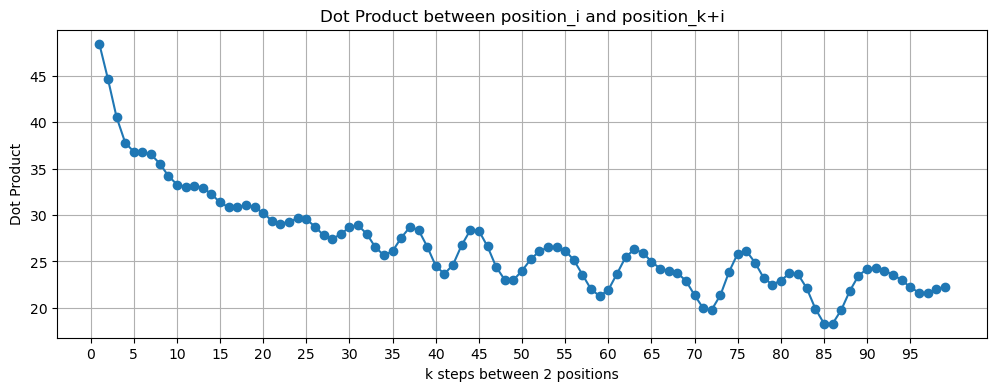

In [16]:
plt.figure(figsize=(12,4))
plt.plot(k_values, dots, marker='o')
plt.xticks(range(0, MAX_SEQUENCE_LENGTH, 5))
plt.title("Dot Product between position_i and position_k+i")
plt.xlabel("k steps between 2 positions")
plt.ylabel("Dot Product")
plt.grid(True)
plt.show()

In [17]:
corr = tf.matmul(pe_matrix[0], pe_matrix[0], transpose_b=True)
corr

<tf.Tensor: shape=(100, 100), dtype=float32, numpy=
array([[50.      , 48.45539 , 44.663754, ..., 21.582405, 22.003847,
        22.27225 ],
       [48.45539 , 50.      , 48.45539 , ..., 21.639723, 21.582407,
        22.003847],
       [44.663754, 48.45539 , 50.000004, ..., 22.226805, 21.639723,
        21.582407],
       ...,
       [21.582405, 21.63972 , 22.226805, ..., 50.      , 48.455383,
        44.663754],
       [22.003847, 21.582407, 21.63972 , ..., 48.455383, 50.      ,
        48.455387],
       [22.27225 , 22.003849, 21.58241 , ..., 44.663754, 48.455387,
        50.      ]], dtype=float32)>

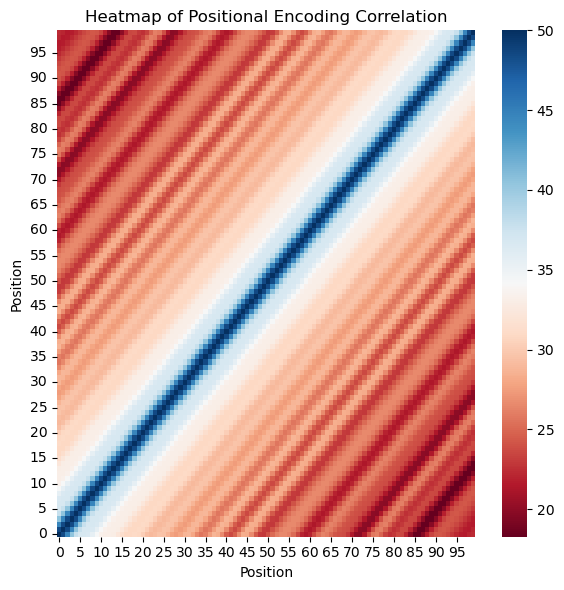

In [18]:
plt.figure(figsize=(6,6))
sns.heatmap(corr, cmap="RdBu", cbar=True, xticklabels=5, yticklabels=5)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.title("Heatmap of Positional Encoding Correlation")
plt.xlabel("Position")
plt.ylabel("Position")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**You can also do it with Euclidean Distance!**

# 2. Semantic Embedding

In [19]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.decomposition import PCA

### Pretrained Embedding Model

**Download here:** https://www.kaggle.com/datasets/rtatman/glove-global-vectors-for-word-representation

In [20]:
GLOVE_FILE = "model/glove.6B.100d.txt/glove.6B.100d.txt"

In [21]:
def read_GloVe_txt(file):
    with open(file, 'r', encoding='utf-8') as f:
        words = set()
        word2vec = {}
        for line in f:
            list = line.strip().split()
            word = list[0]
            vector = np.array(list[1:], dtype=np.float64)
            words.add(word)
            word2vec[word] = vector
    return words, word2vec

In [22]:
words, word2vec = read_GloVe_txt(GLOVE_FILE)

print("Number of words for embedding in GloVe:", len(words))
print("Embedding size of a word in GloVe:", word2vec['the'].shape)

Number of words for embedding in GloVe: 400000
Embedding size of a word in GloVe: (100,)


### Convert a Sequence to a List of Indices with Padding

In [23]:
texts = [
    "The king and the queen met the man and the woman in the garden",
    "The dog chased the wolf while playing with the football and basketball"
]

In [24]:
MAX_VOCAB_SIZE = 64
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>", split=' ', lower=True)
# num_words -- the maximum words in the vocab
# add <OOV> to vocab, if word not in vocab, map it to <OOV>

# Create Vocab
tokenizer.fit_on_texts(texts)

In [25]:
word2idx = tokenizer.word_index
word2idx

{'<OOV>': 1,
 'the': 2,
 'and': 3,
 'king': 4,
 'queen': 5,
 'met': 6,
 'man': 7,
 'woman': 8,
 'in': 9,
 'garden': 10,
 'dog': 11,
 'chased': 12,
 'wolf': 13,
 'while': 14,
 'playing': 15,
 'with': 16,
 'football': 17,
 'basketball': 18}

In [26]:
# Convert Sequence to a List of Indices
idx_sequences = tokenizer.texts_to_sequences(texts)
idx_sequences

[[2, 4, 3, 2, 5, 6, 2, 7, 3, 2, 8, 9, 2, 10],
 [2, 11, 12, 2, 13, 14, 15, 16, 2, 17, 3, 18]]

In [27]:
tokenizer.sequences_to_texts(idx_sequences)

['the king and the queen met the man and the woman in the garden',
 'the dog chased the wolf while playing with the football and basketball']

In [28]:
idx_sequences_padded = pad_sequences(idx_sequences, padding="post", maxlen=MAX_SEQUENCE_LENGTH)
idx_sequences_padded.shape, idx_sequences_padded

((2, 100),
 array([[ 2,  4,  3,  2,  5,  6,  2,  7,  3,  2,  8,  9,  2, 10,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0],
        [ 2, 11, 12,  2, 13, 14, 15, 16,  2, 17,  3, 18,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0]]))

### Embedding Lookup through Indices

In [29]:
def create_embedding_matrix(word2idx, word2vec):
    any_word = next(iter(word2vec))
    embedding_dim = word2vec[any_word].shape[0]  # shape of (n_dims, )
    vocab_size = len(word2idx) + 1  # plus 1 for <PAD> token
        
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    for word, idx in word2idx.items():
        embedding_vector = word2vec.get(word)
        if embedding_vector is not None:
            embedding_matrix[idx] = embedding_vector

    return embedding_matrix

In [30]:
embedding_matrix = create_embedding_matrix(word2idx, word2vec)
embedding_matrix.shape

(19, 100)

In [31]:
vector_pad = embedding_matrix[0]
vector_oov = embedding_matrix[1]

vector_pad, vector_oov
# pad is vector zero, correct
# oov is vector zero, SHOULD NOT BE

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [32]:
embedding_layer = Embedding(
    input_dim=len(word2idx)+1, 
    output_dim=EMBEDDING_DIM,
    embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
    trainable=False
)

In [33]:
embeddings = embedding_layer(idx_sequences_padded)
embeddings.shape  # shape of (batch_size, seq_len, embedding_dim)

TensorShape([2, 100, 100])

# Visualization

In [34]:
def plot_words(embeddings, idx_sequences, word2idx):
    words = list(word2idx.keys())  # idx starts from 0

    for sample_idx, idx_sequence in enumerate(idx_sequences):    
        X = embeddings[sample_idx]    #  pick 1 sample  -->  output_shape (padded_seq_len, embedding_dim)
        X = X[:len(idx_sequence), :]  # output_shape (true_seq_len, embedding_dim)

        # Reduce to 2 dims to plot
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)  # (true_seq_len, 2)
    
        # Plot word
        fig, ax = plt.subplots(figsize=(8, 4))
        plt.rcParams['font.size'] = 12
        ax.scatter(X_pca[:, 0], X_pca[:, 1])
    
        # Naming each point in the graph
        for i, word_idx in enumerate(idx_sequence):
            word = words[word_idx-1]  # word_idx starts from 1
            ax.annotate(word, (X_pca[i, 0], X_pca[i, 1]))

        ax.set_title(f"Sentence {sample_idx}")
        plt.show()

### Only Semantic Embedding

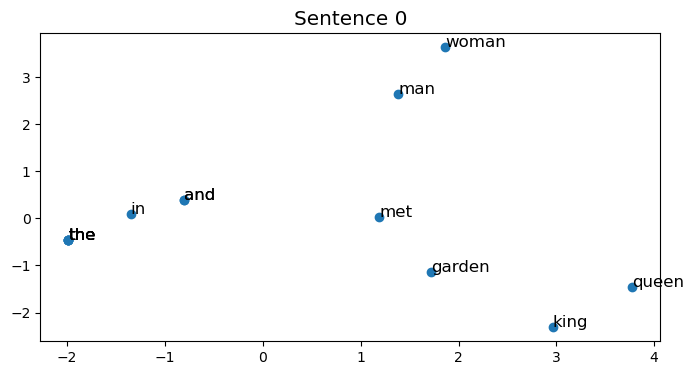

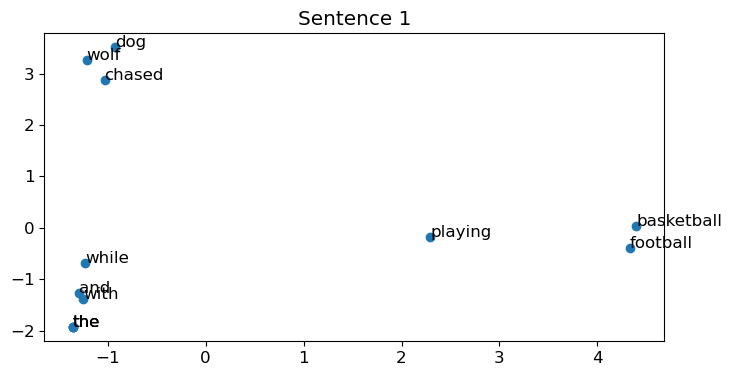

In [35]:
plot_words(embeddings, idx_sequences, word2idx)

### When Semantic Embedding > Positional Encoding

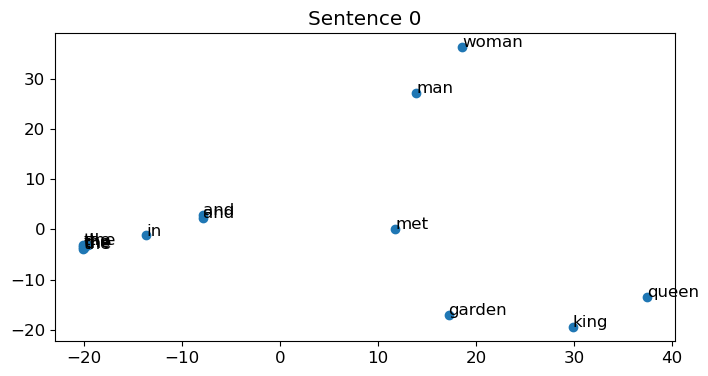

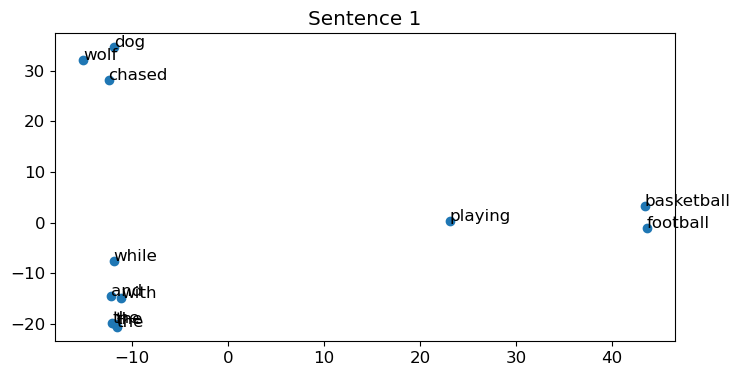

In [36]:
W1 = 10
W2 = 1
weighted_embedding_plus_pe = embeddings * W1 + pe_matrix * W2
plot_words(weighted_embedding_plus_pe, idx_sequences, word2idx)

### When Semantic Embedding < Positional Encoding

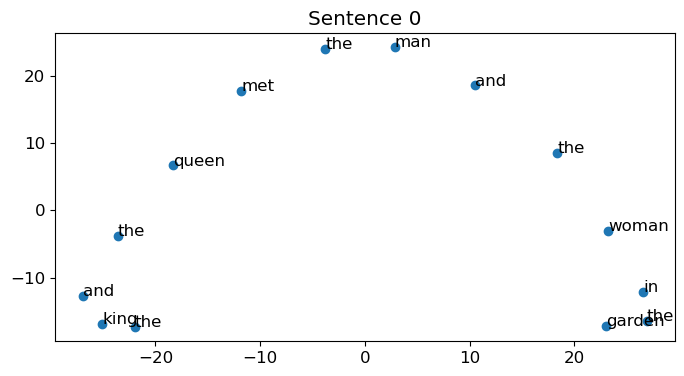

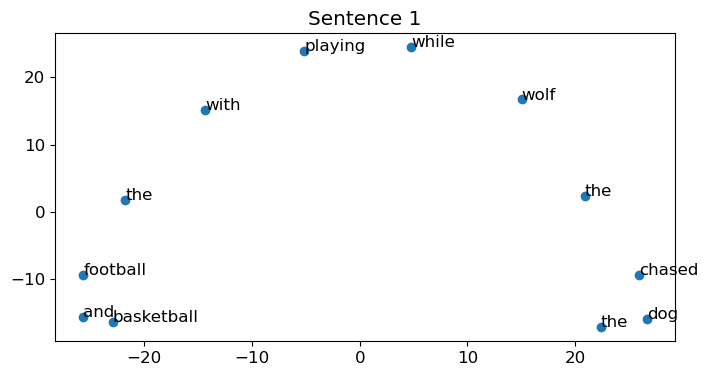

In [37]:
W1 = 1
W2 = 10
weighted_embedding_plus_pe = embeddings * W1 + pe_matrix * W2
plot_words(weighted_embedding_plus_pe, idx_sequences, word2idx)

In [38]:
texts

['The king and the queen met the man and the woman in the garden',
 'The dog chased the wolf while playing with the football and basketball']